# Health Insurance Fraud Detection — Model Experiments (Lightweight Final)

## Objective

This notebook selects the strongest fraud-risk model while keeping execution time reasonable.

The protocol is intentionally strict:

- **Development period**: model fitting and lightweight temporal tuning.
- **Calibration period**: probability calibration only.
- **Validation period**: one common out-of-time comparison for champion selection.
- **Test period (2026)**: completely untouched and reserved for `05_model_evaluation.ipynb`.

### Primary model-selection criteria

Because fraud is rare, **accuracy is not the primary metric**.

We prioritize:

1. Average Precision / PR-AUC;
2. Recall@3% investigation capacity;
3. Precision@3% and Lift@3%;
4. fraud amount captured@3%;
5. ROC-AUC;
6. probability calibration;
7. model simplicity when performances are close.

The objective is not to force the most complex model to win. A simpler model is preferred when it provides equivalent or better out-of-time performance.

## 1. Imports and project setup

In [22]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "interim"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "metadata" / "model_experiments"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

claims = pd.read_parquet(DATA_DIR / "claims.parquet")

print(f"Claims: {len(claims):,}")
print(f"Columns: {claims.shape[1]}")
print(f"Overall fraud prevalence: {claims['is_fraud'].mean():.3%}")

Claims: 99,911
Columns: 55
Overall fraud prevalence: 2.504%


## 2. Rebuild the frozen feature contract

In [23]:
TARGET = "is_fraud"

IDENTIFIER_COLUMNS = [
    "claim_id",
    "customer_id",
    "policy_id",
    "provider_id",
]

LEAKAGE_COLUMNS = [
    "legitimate_anomaly",
    "legitimate_anomaly_type",
    "latent_fraud_score",
    "synthetic_fraud_probability",
    "fraud_difficulty",
    "fraud_mechanism",
]

SYNTHETIC_PROFILE_COLUMNS = [
    "customer_behavior_segment",
    "provider_behavior_segment",
]

RAW_DATE_COLUMNS = [
    "service_date",
    "claim_submission_date",
    "claim_submission_timestamp",
]

# ------------------------------------------------------------------
# Missingness indicators
# ------------------------------------------------------------------

claims["has_prescription_missing"] = (
    claims["has_prescription"].isna().astype("int8")
)

claims["document_count_missing"] = (
    claims["document_count"].isna().astype("int8")
)

claims["provider_missing"] = (
    claims["provider_id"].isna().astype("int8")
)

# ------------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------------

claims["submission_hour"] = (
    claims["claim_submission_timestamp"].dt.hour
)

claims["submission_dayofweek"] = (
    claims["claim_submission_timestamp"].dt.dayofweek
)

claims["submission_month"] = (
    claims["claim_submission_timestamp"].dt.month
)

claims["submission_is_weekend"] = (
    claims["submission_dayofweek"] >= 5
).astype("int8")

claims["service_dayofweek"] = (
    claims["service_date"].dt.dayofweek
)

claims["service_month"] = (
    claims["service_date"].dt.month
)

claims["service_is_weekend"] = (
    claims["service_dayofweek"] >= 5
).astype("int8")

# ------------------------------------------------------------------
# Contextual business features
# ------------------------------------------------------------------

EPS = 1e-6

claims["requested_to_limit_ratio"] = (
    claims["requested_reimbursement"]
    / claims["coverage_limit"].clip(lower=EPS)
)

claims["amount_above_service_typical"] = (
    claims["claim_amount"]
    - claims["service_typical_amount"]
)

claims["recent_claim_share_30d_365d"] = (
    claims["customer_claims_30d"]
    / claims["customer_claims_365d"].replace(0, np.nan)
)

claims["recent_amount_share_30d_365d"] = (
    claims["customer_amount_30d"]
    / claims["customer_amount_365d"].replace(0, np.nan)
)

claims["provider_recent_activity_ratio"] = (
    (claims["provider_claims_30d"] + 1)
    / (claims["provider_claims_90d"] / 3 + 1)
)

claims["customer_provider_intensity"] = (
    claims["customer_provider_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["same_service_intensity"] = (
    claims["same_service_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["days_since_policy_change_missing"] = (
    claims["days_since_policy_change"].isna().astype("int8")
)

MODEL_EXCLUSIONS = (
    IDENTIFIER_COLUMNS
    + LEAKAGE_COLUMNS
    + SYNTHETIC_PROFILE_COLUMNS
    + RAW_DATE_COLUMNS
    + [TARGET]
)

FEATURES = [
    column
    for column in claims.columns
    if column not in MODEL_EXCLUSIONS
]

assert not set(LEAKAGE_COLUMNS).intersection(FEATURES)
assert not set(IDENTIFIER_COLUMNS).intersection(FEATURES)

print(f"Model features: {len(FEATURES)}")
print("Leakage audit: PASS")

Model features: 57
Leakage audit: PASS


### Governance note

The synthetic variables `fraud_mechanism`, `fraud_difficulty`, `latent_fraud_score`, `synthetic_fraud_probability` and legitimate-anomaly metadata are excluded from the model.

They may only be used **after scoring** for diagnostic analysis.

## 3. Temporal experiment design

In [24]:
TRAIN_END = pd.Timestamp("2025-06-30 23:59:59")
VALIDATION_END = pd.Timestamp("2025-12-31 23:59:59")

# Last three months of the original training era are reserved for calibration.
DEVELOPMENT_END = pd.Timestamp("2025-03-31 23:59:59")

development = claims.loc[
    claims["claim_submission_timestamp"] <= DEVELOPMENT_END
].copy()

calibration = claims.loc[
    (claims["claim_submission_timestamp"] > DEVELOPMENT_END)
    & (claims["claim_submission_timestamp"] <= TRAIN_END)
].copy()

validation = claims.loc[
    (claims["claim_submission_timestamp"] > TRAIN_END)
    & (claims["claim_submission_timestamp"] <= VALIDATION_END)
].copy()

test_mask = (
    claims["claim_submission_timestamp"] > VALIDATION_END
)

period_summary = pd.DataFrame(
    [
        {
            "period": "development",
            "rows": len(development),
            "fraud_cases": int(development[TARGET].sum()),
            "fraud_rate_pct": development[TARGET].mean() * 100,
            "purpose": "fit + tune",
        },
        {
            "period": "calibration",
            "rows": len(calibration),
            "fraud_cases": int(calibration[TARGET].sum()),
            "fraud_rate_pct": calibration[TARGET].mean() * 100,
            "purpose": "probability calibration",
        },
        {
            "period": "validation",
            "rows": len(validation),
            "fraud_cases": int(validation[TARGET].sum()),
            "fraud_rate_pct": validation[TARGET].mean() * 100,
            "purpose": "champion selection",
        },
        {
            "period": "test_held_out",
            "rows": int(test_mask.sum()),
            "fraud_cases": int(
                claims.loc[test_mask, TARGET].sum()
            ),
            "fraud_rate_pct": (
                claims.loc[test_mask, TARGET].mean() * 100
            ),
            "purpose": "05 only",
        },
    ]
)

period_summary

,period,rows,fraud_cases,fraud_rate_pct,purpose
0,development,64404,1567,2.4331,fit + tune
1,calibration,6944,134,1.9297,probability calibration
2,validation,14387,392,2.7247,champion selection
3,test_held_out,14176,409,2.8852,05 only


The 2026 test set is only counted here. It is **not transformed, scored or used for tuning**.

## 4. Preprocessing

In [25]:
BOOLEAN_FEATURES = [
    column
    for column in FEATURES
    if (
        pd.api.types.is_bool_dtype(claims[column])
        or column.endswith("_missing")
        or column.endswith("_is_weekend")
        or column == "provider_missing"
    )
]

CATEGORICAL_FEATURES = [
    column
    for column in FEATURES
    if pd.api.types.is_object_dtype(claims[column])
]

NUMERIC_FEATURES = [
    column
    for column in FEATURES
    if (
        pd.api.types.is_numeric_dtype(claims[column])
        and column not in BOOLEAN_FEATURES
    )
]

print(f"Numeric features:     {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Boolean features:     {len(BOOLEAN_FEATURES)}")

Numeric features:     42
Categorical features: 7
Boolean features:     8


In [26]:
def build_preprocessor():
    numeric_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                ),
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=10,
                ),
            ),
        ]
    )

    boolean_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES,
            ),
            (
                "boolean",
                boolean_pipeline,
                BOOLEAN_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [27]:
preprocessor = build_preprocessor()

X_dev = development[FEATURES]
y_dev = development[TARGET].astype(int)

X_cal = calibration[FEATURES]
y_cal = calibration[TARGET].astype(int)

X_val = validation[FEATURES]
y_val = validation[TARGET].astype(int)

X_dev_t = preprocessor.fit_transform(X_dev)
X_cal_t = preprocessor.transform(X_cal)
X_val_t = preprocessor.transform(X_val)

print(f"Development matrix: {X_dev_t.shape}")
print(f"Calibration matrix: {X_cal_t.shape}")
print(f"Validation matrix:  {X_val_t.shape}")

Development matrix: (64404, 107)
Calibration matrix: (6944, 107)
Validation matrix:  (14387, 107)


## 5. Evaluation metrics

In [28]:
def ranking_metrics(
    y_true,
    probabilities,
):
    return {
        "average_precision": average_precision_score(
            y_true,
            probabilities,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "brier_score": brier_score_loss(
            y_true,
            probabilities,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1],
        ),
    }


def top_k_metrics(
    y_true,
    probabilities,
    claim_amounts,
    review_fraction=0.03,
):
    y = np.asarray(y_true)
    p = np.asarray(probabilities)
    amounts = np.asarray(claim_amounts)

    k = max(
        1,
        int(
            np.ceil(
                len(y)
                * review_fraction
            )
        ),
    )

    selected = np.argsort(-p)[:k]
    selected_y = y[selected]

    precision_at_k = selected_y.mean()
    recall_at_k = (
        selected_y.sum()
        / max(y.sum(), 1)
    )

    prevalence = y.mean()

    lift_at_k = (
        precision_at_k / prevalence
        if prevalence > 0
        else np.nan
    )

    total_fraud_amount = (
        amounts[y == 1].sum()
    )

    captured_fraud_amount = (
        amounts[selected][
            selected_y == 1
        ].sum()
    )

    amount_capture = (
        captured_fraud_amount
        / total_fraud_amount
        if total_fraud_amount > 0
        else np.nan
    )

    return {
        "precision_at_3pct": precision_at_k,
        "recall_at_3pct": recall_at_k,
        "lift_at_3pct": lift_at_k,
        "fraud_amount_capture_at_3pct": amount_capture,
    }


def complete_metrics(
    name,
    y_true,
    probabilities,
    claim_amounts,
):
    return {
        "model": name,
        **ranking_metrics(
            y_true,
            probabilities,
        ),
        **top_k_metrics(
            y_true,
            probabilities,
            claim_amounts,
            review_fraction=0.03,
        ),
    }

## 6. Lightweight temporal cross-validation

We use only **two expanding temporal folds** inside the development period.

This preserves out-of-time validation while reducing compute significantly.

In [29]:
DEV_FOLDS = [
    {
        "train_end": pd.Timestamp("2024-06-30 23:59:59"),
        "eval_start": pd.Timestamp("2024-07-01"),
        "eval_end": pd.Timestamp("2024-12-31 23:59:59"),
    },
    {
        "train_end": pd.Timestamp("2024-12-31 23:59:59"),
        "eval_start": pd.Timestamp("2025-01-01"),
        "eval_end": pd.Timestamp("2025-03-31 23:59:59"),
    },
]

pd.DataFrame(DEV_FOLDS)

,train_end,eval_start,eval_end
0,2024-06-30 23:59:59,2024-07-01,2024-12-31 23:59:59
1,2024-12-31 23:59:59,2025-01-01,2025-03-31 23:59:59


In [30]:
def temporal_cv_score(
    model_factory,
    params,
):
    rows = []

    for fold_id, fold in enumerate(
        DEV_FOLDS,
        start=1,
    ):
        fit_df = development.loc[
            development[
                "claim_submission_timestamp"
            ]
            <= fold["train_end"]
        ].copy()

        eval_df = development.loc[
            development[
                "claim_submission_timestamp"
            ].between(
                fold["eval_start"],
                fold["eval_end"],
            )
        ].copy()

        fold_preprocessor = build_preprocessor()

        X_fit = (
            fold_preprocessor
            .fit_transform(
                fit_df[FEATURES]
            )
        )

        X_eval = (
            fold_preprocessor
            .transform(
                eval_df[FEATURES]
            )
        )

        model = model_factory(params)

        start = perf_counter()

        model.fit(
            X_fit,
            fit_df[TARGET].astype(int),
        )

        fit_seconds = (
            perf_counter() - start
        )

        probabilities = (
            model
            .predict_proba(X_eval)[:, 1]
        )

        capacity = top_k_metrics(
            eval_df[TARGET],
            probabilities,
            eval_df["claim_amount"],
            0.03,
        )

        rows.append(
            {
                "fold": fold_id,
                "average_precision": (
                    average_precision_score(
                        eval_df[TARGET],
                        probabilities,
                    )
                ),
                "roc_auc": (
                    roc_auc_score(
                        eval_df[TARGET],
                        probabilities,
                    )
                ),
                "recall_at_3pct": (
                    capacity[
                        "recall_at_3pct"
                    ]
                ),
                "precision_at_3pct": (
                    capacity[
                        "precision_at_3pct"
                    ]
                ),
                "fit_seconds": fit_seconds,
            }
        )

    fold_results = pd.DataFrame(rows)

    return {
        "mean_ap": (
            fold_results[
                "average_precision"
            ].mean()
        ),
        "std_ap": (
            fold_results[
                "average_precision"
            ].std(ddof=0)
        ),
        "mean_roc_auc": (
            fold_results[
                "roc_auc"
            ].mean()
        ),
        "mean_recall_at_3pct": (
            fold_results[
                "recall_at_3pct"
            ].mean()
        ),
        "mean_precision_at_3pct": (
            fold_results[
                "precision_at_3pct"
            ].mean()
        ),
        "total_fit_seconds": (
            fold_results[
                "fit_seconds"
            ].sum()
        ),
        "fold_results": fold_results,
    }

## 7. Logistic Regression tuning

Logistic Regression is inexpensive and was already highly competitive, so we explore it slightly more thoroughly than the tree models.

In [31]:
def make_logistic(params):
    return LogisticRegression(
        C=params["C"],
        penalty="l2",
        class_weight=params["class_weight"],
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_SEED,
    )


logistic_grid = [
    {"C": 0.05, "class_weight": None},
    {"C": 0.20, "class_weight": None},
    {"C": 1.00, "class_weight": None},
    {"C": 5.00, "class_weight": None},
    {"C": 0.20, "class_weight": "balanced"},
    {"C": 1.00, "class_weight": "balanced"},
]


logistic_rows = []

for i, params in enumerate(
    logistic_grid,
    start=1,
):
    print(
        f"Logistic {i}/{len(logistic_grid)} "
        f"{params}"
    )

    cv = temporal_cv_score(
        make_logistic,
        params,
    )

    logistic_rows.append(
        {
            **params,
            "mean_ap": cv["mean_ap"],
            "std_ap": cv["std_ap"],
            "mean_roc_auc": (
                cv["mean_roc_auc"]
            ),
            "mean_recall_at_3pct": (
                cv[
                    "mean_recall_at_3pct"
                ]
            ),
            "mean_precision_at_3pct": (
                cv[
                    "mean_precision_at_3pct"
                ]
            ),
            "fit_seconds": (
                cv[
                    "total_fit_seconds"
                ]
            ),
        }
    )


logistic_tuning = (
    pd.DataFrame(logistic_rows)
    .sort_values(
        [
            "mean_ap",
            "mean_recall_at_3pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_tuning

Logistic 1/6 {'C': 0.05, 'class_weight': None}
Logistic 2/6 {'C': 0.2, 'class_weight': None}
Logistic 3/6 {'C': 1.0, 'class_weight': None}
Logistic 4/6 {'C': 5.0, 'class_weight': None}
Logistic 5/6 {'C': 0.2, 'class_weight': 'balanced'}
Logistic 6/6 {'C': 1.0, 'class_weight': 'balanced'}


,C,class_weight,mean_ap,std_ap,mean_roc_auc,mean_recall_at_3pct,mean_precision_at_3pct,fit_seconds
0,0.2000,balanced,0.4598,0.0279,0.8080,0.5025,0.3985,2.5896
1,1.0000,balanced,0.4597,0.0278,0.8078,0.5025,0.3985,2.6471
2,0.0500,None,0.4483,0.0496,0.8021,0.4829,0.3846,1.6104
3,0.2000,None,0.4480,0.0477,0.8001,0.4863,0.3869,1.5297
4,5.0000,None,0.4473,0.0480,0.7983,0.4863,0.3869,1.0798
5,1.0000,None,0.4472,0.0485,0.7986,0.4863,0.3869,0.9794


In [32]:
best_logistic_row = (
    logistic_tuning.iloc[0]
)

best_logistic_params = {
    "C": float(
        best_logistic_row["C"]
    ),
    "class_weight": (
        None
        if pd.isna(
            best_logistic_row[
                "class_weight"
            ]
        )
        else best_logistic_row[
            "class_weight"
        ]
    ),
}

best_logistic_params

{'C': 0.2, 'class_weight': 'balanced'}

## 8. Random Forest tuning — lightweight

In [33]:
def make_rf(params):
    return RandomForestClassifier(
        n_estimators=180,
        max_depth=params["max_depth"],
        min_samples_leaf=params[
            "min_samples_leaf"
        ],
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )


rf_grid = [
    {
        "max_depth": 10,
        "min_samples_leaf": 5,
    },
    {
        "max_depth": 14,
        "min_samples_leaf": 8,
    },
    {
        "max_depth": None,
        "min_samples_leaf": 12,
    },
]


rf_rows = []

for i, params in enumerate(
    rf_grid,
    start=1,
):
    print(
        f"Random Forest "
        f"{i}/{len(rf_grid)} "
        f"{params}"
    )

    cv = temporal_cv_score(
        make_rf,
        params,
    )

    rf_rows.append(
        {
            **params,
            "mean_ap": cv["mean_ap"],
            "std_ap": cv["std_ap"],
            "mean_roc_auc": (
                cv["mean_roc_auc"]
            ),
            "mean_recall_at_3pct": (
                cv[
                    "mean_recall_at_3pct"
                ]
            ),
            "mean_precision_at_3pct": (
                cv[
                    "mean_precision_at_3pct"
                ]
            ),
            "fit_seconds": (
                cv[
                    "total_fit_seconds"
                ]
            ),
        }
    )


rf_tuning = (
    pd.DataFrame(rf_rows)
    .sort_values(
        [
            "mean_ap",
            "mean_recall_at_3pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

rf_tuning

Random Forest 1/3 {'max_depth': 10, 'min_samples_leaf': 5}
Random Forest 2/3 {'max_depth': 14, 'min_samples_leaf': 8}
Random Forest 3/3 {'max_depth': None, 'min_samples_leaf': 12}


,max_depth,min_samples_leaf,mean_ap,std_ap,mean_roc_auc,mean_recall_at_3pct,mean_precision_at_3pct,fit_seconds
0,NaN,12,0.4508,0.0567,0.8142,0.4897,0.3892,29.2246
1,14.0000,8,0.4434,0.0541,0.8186,0.4919,0.3904,26.8565
2,10.0000,5,0.4327,0.0529,0.8269,0.4697,0.3742,21.9825


In [34]:
best_rf_row = rf_tuning.iloc[0]

best_rf_params = {
    "max_depth": (
        None
        if pd.isna(
            best_rf_row[
                "max_depth"
            ]
        )
        else int(
            best_rf_row[
                "max_depth"
            ]
        )
    ),
    "min_samples_leaf": int(
        best_rf_row[
            "min_samples_leaf"
        ]
    ),
}

best_rf_params

{'max_depth': None, 'min_samples_leaf': 12}

## 9. XGBoost tuning — lightweight

In [35]:
dev_negative = int(
    (y_dev == 0).sum()
)

dev_positive = int(
    (y_dev == 1).sum()
)

dev_scale_pos_weight = (
    dev_negative
    / dev_positive
)

print(
    "Development scale_pos_weight:",
    f"{dev_scale_pos_weight:.2f}",
)

Development scale_pos_weight: 40.10


In [36]:
def make_xgb(params):
    return XGBClassifier(
        objective="binary:logistic",
        n_estimators=350,
        learning_rate=params[
            "learning_rate"
        ],
        max_depth=params[
            "max_depth"
        ],
        min_child_weight=params[
            "min_child_weight"
        ],
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=params[
            "reg_alpha"
        ],
        reg_lambda=params[
            "reg_lambda"
        ],
        scale_pos_weight=params[
            "scale_pos_weight"
        ],
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )


xgb_grid = [
    # Conservative
    {
        "learning_rate": 0.04,
        "max_depth": 3,
        "min_child_weight": 4,
        "reg_alpha": 0.00,
        "reg_lambda": 2.0,
        "scale_pos_weight": 1.0,
    },

    # Balanced / class-weighted
    {
        "learning_rate": 0.035,
        "max_depth": 5,
        "min_child_weight": 4,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
        "scale_pos_weight": (
            dev_scale_pos_weight
        ),
    },

    # Flexible but regularized
    {
        "learning_rate": 0.03,
        "max_depth": 6,
        "min_child_weight": 8,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "scale_pos_weight": 1.0,
    },
]


xgb_rows = []

for i, params in enumerate(
    xgb_grid,
    start=1,
):
    print(
        f"XGBoost "
        f"{i}/{len(xgb_grid)}"
    )

    cv = temporal_cv_score(
        make_xgb,
        params,
    )

    xgb_rows.append(
        {
            **params,
            "mean_ap": cv["mean_ap"],
            "std_ap": cv["std_ap"],
            "mean_roc_auc": (
                cv["mean_roc_auc"]
            ),
            "mean_recall_at_3pct": (
                cv[
                    "mean_recall_at_3pct"
                ]
            ),
            "mean_precision_at_3pct": (
                cv[
                    "mean_precision_at_3pct"
                ]
            ),
            "fit_seconds": (
                cv[
                    "total_fit_seconds"
                ]
            ),
        }
    )


xgb_tuning = (
    pd.DataFrame(xgb_rows)
    .sort_values(
        [
            "mean_ap",
            "mean_recall_at_3pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

xgb_tuning

XGBoost 1/3
XGBoost 2/3
XGBoost 3/3


,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,scale_pos_weight,mean_ap,std_ap,mean_roc_auc,mean_recall_at_3pct,mean_precision_at_3pct,fit_seconds
0,0.0400,3,4,0.0000,2.0000,1.0000,0.4744,0.0601,0.8296,0.4952,0.3949,5.6746
1,0.0300,6,8,0.1000,3.0000,1.0000,0.4542,0.0650,0.8244,0.4833,0.3857,8.7827
2,0.0350,5,4,0.0500,2.0000,40.1002,0.4210,0.0564,0.7977,0.4415,0.3533,7.4271


In [37]:
best_xgb_row = xgb_tuning.iloc[0]

best_xgb_params = {
    "learning_rate": float(
        best_xgb_row[
            "learning_rate"
        ]
    ),
    "max_depth": int(
        best_xgb_row[
            "max_depth"
        ]
    ),
    "min_child_weight": int(
        best_xgb_row[
            "min_child_weight"
        ]
    ),
    "reg_alpha": float(
        best_xgb_row[
            "reg_alpha"
        ]
    ),
    "reg_lambda": float(
        best_xgb_row[
            "reg_lambda"
        ]
    ),
    "scale_pos_weight": float(
        best_xgb_row[
            "scale_pos_weight"
        ]
    ),
}

best_xgb_params

{'learning_rate': 0.04,
 'max_depth': 3,
 'min_child_weight': 4,
 'reg_alpha': 0.0,
 'reg_lambda': 2.0,
 'scale_pos_weight': 1.0}

## 10. Temporal tuning comparison

In [38]:
tuning_summary = pd.DataFrame(
    [
        {
            "model": "Logistic regression",
            "mean_cv_ap": (
                logistic_tuning.iloc[0][
                    "mean_ap"
                ]
            ),
            "std_cv_ap": (
                logistic_tuning.iloc[0][
                    "std_ap"
                ]
            ),
            "mean_cv_roc_auc": (
                logistic_tuning.iloc[0][
                    "mean_roc_auc"
                ]
            ),
            "mean_cv_recall_at_3pct": (
                logistic_tuning.iloc[0][
                    "mean_recall_at_3pct"
                ]
            ),
            "tuning_seconds": (
                logistic_tuning[
                    "fit_seconds"
                ].sum()
            ),
        },
        {
            "model": "Random forest",
            "mean_cv_ap": (
                rf_tuning.iloc[0][
                    "mean_ap"
                ]
            ),
            "std_cv_ap": (
                rf_tuning.iloc[0][
                    "std_ap"
                ]
            ),
            "mean_cv_roc_auc": (
                rf_tuning.iloc[0][
                    "mean_roc_auc"
                ]
            ),
            "mean_cv_recall_at_3pct": (
                rf_tuning.iloc[0][
                    "mean_recall_at_3pct"
                ]
            ),
            "tuning_seconds": (
                rf_tuning[
                    "fit_seconds"
                ].sum()
            ),
        },
        {
            "model": "XGBoost",
            "mean_cv_ap": (
                xgb_tuning.iloc[0][
                    "mean_ap"
                ]
            ),
            "std_cv_ap": (
                xgb_tuning.iloc[0][
                    "std_ap"
                ]
            ),
            "mean_cv_roc_auc": (
                xgb_tuning.iloc[0][
                    "mean_roc_auc"
                ]
            ),
            "mean_cv_recall_at_3pct": (
                xgb_tuning.iloc[0][
                    "mean_recall_at_3pct"
                ]
            ),
            "tuning_seconds": (
                xgb_tuning[
                    "fit_seconds"
                ].sum()
            ),
        },
    ]
).sort_values(
    "mean_cv_ap",
    ascending=False,
)

tuning_summary

,model,mean_cv_ap,std_cv_ap,mean_cv_roc_auc,mean_cv_recall_at_3pct,tuning_seconds
2,XGBoost,0.4744,0.0601,0.8296,0.4952,21.8844
0,Logistic regression,0.4598,0.0279,0.8080,0.5025,10.4360
1,Random forest,0.4508,0.0567,0.8142,0.4897,78.0636


## 11. Fit final candidate models on development

In [39]:
dummy = DummyClassifier(
    strategy="prior",
)

best_logistic = (
    make_logistic(
        best_logistic_params
    )
)

best_rf = (
    make_rf(
        best_rf_params
    )
)

best_xgb = (
    make_xgb(
        best_xgb_params
    )
)


final_models = {
    "Dummy prior": dummy,
    "Logistic regression": best_logistic,
    "Random forest": best_rf,
    "XGBoost": best_xgb,
}


raw_validation_probabilities = {}
calibration_probabilities = {}


for name, model in final_models.items():
    print(f"Fitting {name}...")

    model.fit(
        X_dev_t,
        y_dev,
    )

    raw_validation_probabilities[
        name
    ] = (
        model
        .predict_proba(X_val_t)[:, 1]
    )

Fitting Dummy prior...
Fitting Logistic regression...
Fitting Random forest...
Fitting XGBoost...


## 12. Lightweight probability calibration

Calibration is learned on the later calibration period.

To keep the notebook fast and robust, only **Platt scaling** is used for model calibration.

Platt scaling is inexpensive, stable and particularly appropriate when calibration data is limited.

In [40]:
def fit_platt_calibrator(
    model,
    X_calibration,
    y_calibration,
):
    raw = (
        model
        .predict_proba(
            X_calibration
        )[:, 1]
    )

    eps = 1e-6

    logits = np.log(
        np.clip(
            raw,
            eps,
            1 - eps,
        )
        / np.clip(
            1 - raw,
            eps,
            1 - eps,
        )
    ).reshape(-1, 1)

    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=1000,
    )

    calibrator.fit(
        logits,
        y_calibration,
    )

    return calibrator


def apply_platt(
    model,
    calibrator,
    X,
):
    raw = (
        model
        .predict_proba(X)[:, 1]
    )

    eps = 1e-6

    logits = np.log(
        np.clip(
            raw,
            eps,
            1 - eps,
        )
        / np.clip(
            1 - raw,
            eps,
            1 - eps,
        )
    ).reshape(-1, 1)

    return (
        calibrator
        .predict_proba(logits)[:, 1]
    )

In [41]:
for name in [
    "Logistic regression",
    "Random forest",
    "XGBoost",
]:
    model = final_models[name]

    calibrator = (
        fit_platt_calibrator(
            model,
            X_cal_t,
            y_cal,
        )
    )

    calibration_probabilities[
        name
    ] = apply_platt(
        model,
        calibrator,
        X_val_t,
    )

## 13. Raw vs calibrated probability quality

In [42]:
calibration_rows = []

for name in [
    "Logistic regression",
    "Random forest",
    "XGBoost",
]:
    for calibration_name, probabilities in [
        (
            "raw",
            raw_validation_probabilities[
                name
            ],
        ),
        (
            "platt",
            calibration_probabilities[
                name
            ],
        ),
    ]:
        calibration_rows.append(
            {
                "model": name,
                "calibration": calibration_name,
                **ranking_metrics(
                    y_val,
                    probabilities,
                ),
            }
        )


calibration_comparison = (
    pd.DataFrame(
        calibration_rows
    )
    .sort_values(
        [
            "model",
            "brier_score",
        ],
        ascending=[
            True,
            True,
        ],
    )
)

calibration_comparison

,model,calibration,average_precision,roc_auc,brier_score,log_loss
1,Logistic regression,platt,0.4780,0.8311,0.0184,0.0853
0,Logistic regression,raw,0.4780,0.8311,0.1312,0.4403
3,Random forest,platt,0.4390,0.8339,0.0197,0.0878
2,Random forest,raw,0.4390,0.8339,0.0279,0.1373
4,XGBoost,raw,0.4846,0.8451,0.0183,0.0825
5,XGBoost,platt,0.4846,0.8451,0.0186,0.0838


Calibration is selected using Brier score and log loss.

Average Precision and ROC-AUC should remain essentially unchanged because calibration is a monotonic score transformation.

In [43]:
best_probability_method = {}

for name in [
    "Logistic regression",
    "Random forest",
    "XGBoost",
]:
    subset = (
        calibration_comparison
        .loc[
            calibration_comparison[
                "model"
            ]
            == name
        ]
        .sort_values(
            [
                "brier_score",
                "log_loss",
            ]
        )
    )

    best_probability_method[
        name
    ] = (
        subset.iloc[0][
            "calibration"
        ]
    )

best_probability_method

{'Logistic regression': 'platt', 'Random forest': 'platt', 'XGBoost': 'raw'}

## 14. Final validation scorecard

In [44]:
score_rows = [
    complete_metrics(
        "Dummy prior",
        y_val,
        raw_validation_probabilities[
            "Dummy prior"
        ],
        validation[
            "claim_amount"
        ],
    )
]


final_probabilities = {}


for name in [
    "Logistic regression",
    "Random forest",
    "XGBoost",
]:
    method = (
        best_probability_method[
            name
        ]
    )

    probabilities = (
        raw_validation_probabilities[
            name
        ]
        if method == "raw"
        else calibration_probabilities[
            name
        ]
    )

    final_probabilities[
        name
    ] = probabilities

    score_rows.append(
        complete_metrics(
            f"{name} [{method}]",
            y_val,
            probabilities,
            validation[
                "claim_amount"
            ],
        )
    )


validation_scorecard = (
    pd.DataFrame(score_rows)
    .sort_values(
        [
            "average_precision",
            "recall_at_3pct",
            "brier_score",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

validation_scorecard

,model,average_precision,roc_auc,brier_score,log_loss,precision_at_3pct,recall_at_3pct,lift_at_3pct,fraud_amount_capture_at_3pct
0,XGBoost [raw],0.4846,0.8451,0.0183,0.0825,0.4653,0.5128,17.0764,0.4907
1,Logistic regression [platt],0.4780,0.8311,0.0184,0.0853,0.4421,0.4872,16.2268,0.4769
2,Random forest [platt],0.4390,0.8339,0.0197,0.0878,0.4144,0.4566,15.2073,0.4132
3,Dummy prior,0.0272,0.5000,0.0265,0.1252,0.0509,0.0561,1.8691,0.0457


## 15. Precision–Recall curves

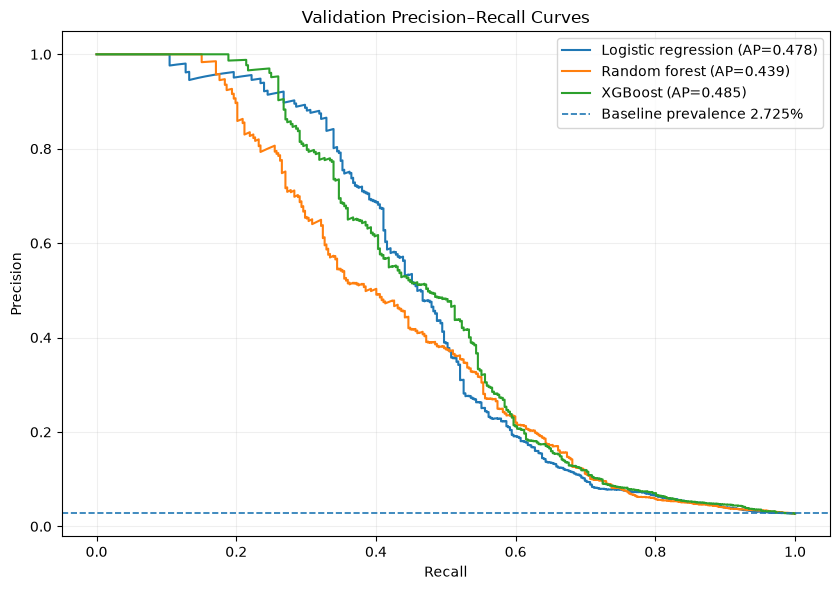

In [45]:
fig, ax = plt.subplots(
    figsize=(8.5, 6)
)

for name, probabilities in (
    final_probabilities.items()
):
    precision, recall, _ = (
        precision_recall_curve(
            y_val,
            probabilities,
        )
    )

    ap = (
        average_precision_score(
            y_val,
            probabilities,
        )
    )

    ax.plot(
        recall,
        precision,
        label=(
            f"{name} "
            f"(AP={ap:.3f})"
        ),
    )

ax.axhline(
    y_val.mean(),
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Baseline prevalence "
        f"{y_val.mean():.3%}"
    ),
)

ax.set_title(
    "Validation Precision–Recall Curves"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 16. Calibration curves

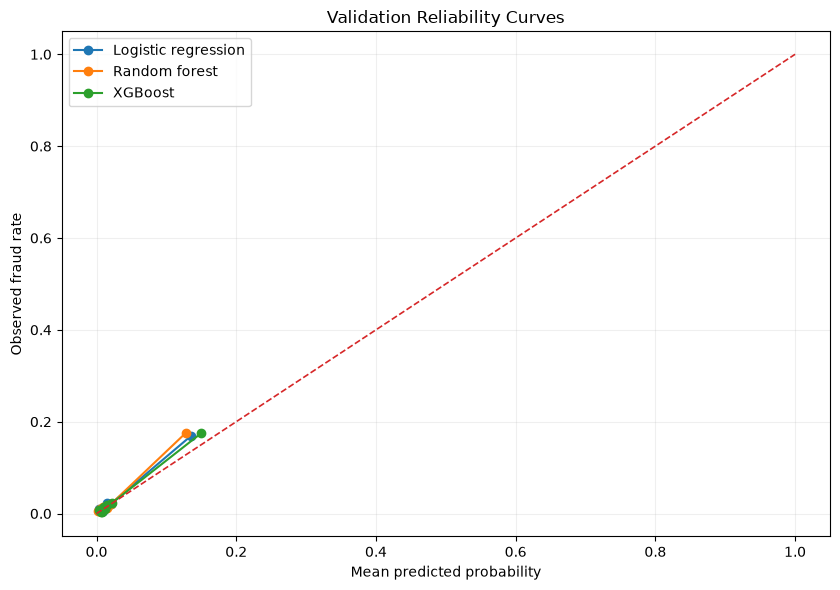

In [46]:
fig, ax = plt.subplots(
    figsize=(8.5, 6)
)

for name, probabilities in (
    final_probabilities.items()
):
    prob_true, prob_pred = (
        calibration_curve(
            y_val,
            probabilities,
            n_bins=10,
            strategy="quantile",
        )
    )

    ax.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=name,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
)

ax.set_title(
    "Validation Reliability Curves"
)

ax.set_xlabel(
    "Mean predicted probability"
)

ax.set_ylabel(
    "Observed fraud rate"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 17. Investigation capacity analysis

In [47]:
def capacity_curve(
    y_true,
    probabilities,
    amounts,
):
    rows = []

    for fraction in [
        0.01,
        0.02,
        0.03,
        0.05,
        0.10,
    ]:
        metrics = top_k_metrics(
            y_true,
            probabilities,
            amounts,
            review_fraction=fraction,
        )

        rows.append(
            {
                "review_fraction": fraction,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


capacity_frames = []

for name, probabilities in (
    final_probabilities.items()
):
    frame = capacity_curve(
        y_val,
        probabilities,
        validation[
            "claim_amount"
        ],
    )

    frame["model"] = name

    capacity_frames.append(
        frame
    )


capacity_results = (
    pd.concat(
        capacity_frames,
        ignore_index=True,
    )
)

capacity_results

,review_fraction,precision_at_3pct,recall_at_3pct,lift_at_3pct,fraud_amount_capture_at_3pct,model
0,0.0100,0.8750,0.3214,32.1138,0.2970,Logistic regression
1,0.0200,0.5799,0.4260,21.2818,0.3952,Logistic regression
2,0.0300,0.4421,0.4872,16.2268,0.4769,Logistic regression
3,0.0500,0.2861,0.5255,10.5007,0.5424,Logistic regression
4,0.1000,0.1696,0.6224,6.2232,0.6392,Logistic regression
5,0.0100,0.7361,0.2704,27.0164,0.2240,Random forest
6,0.0200,0.5104,0.3750,18.7331,0.3399,Random forest
7,0.0300,0.4144,0.4566,15.2073,0.4132,Random forest
8,0.0500,0.3014,0.5536,11.0614,0.5393,Random forest
9,0.1000,0.1751,0.6429,6.4272,0.6865,Random forest


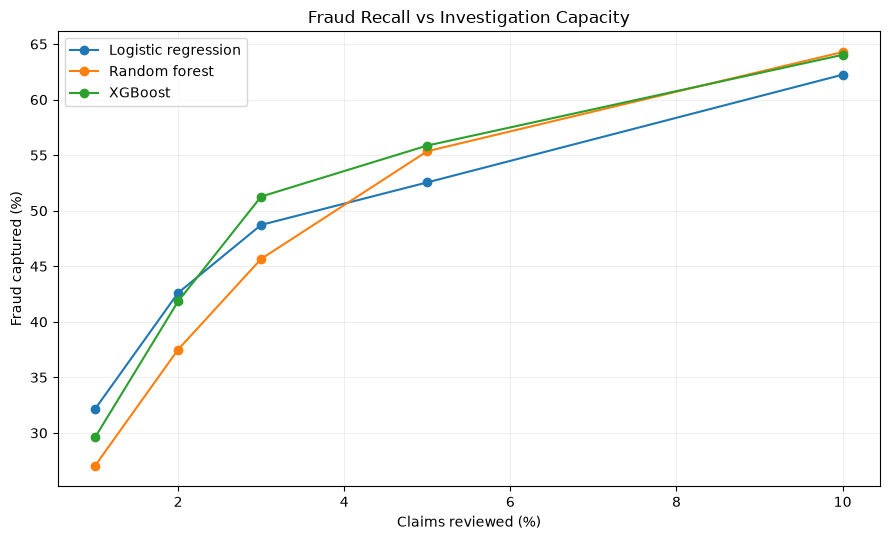

In [48]:
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

for name, group in (
    capacity_results.groupby(
        "model"
    )
):
    ax.plot(
        group[
            "review_fraction"
        ]
        * 100,
        group[
            "recall_at_3pct"
        ]
        * 100,
        marker="o",
        label=name,
    )

ax.set_title(
    "Fraud Recall vs Investigation Capacity"
)

ax.set_xlabel(
    "Claims reviewed (%)"
)

ax.set_ylabel(
    "Fraud captured (%)"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 18. Select validation champion

In [49]:
champion = (
    validation_scorecard.iloc[0]
)

print("VALIDATION CHAMPION")
print("-------------------")

print(
    f"Model:                  "
    f"{champion['model']}"
)

print(
    f"Average Precision:      "
    f"{champion['average_precision']:.4f}"
)

print(
    f"ROC-AUC:                "
    f"{champion['roc_auc']:.4f}"
)

print(
    f"Brier score:            "
    f"{champion['brier_score']:.4f}"
)

print(
    f"Precision @ 3%:         "
    f"{champion['precision_at_3pct']:.3%}"
)

print(
    f"Recall @ 3%:            "
    f"{champion['recall_at_3pct']:.3%}"
)

print(
    f"Lift @ 3%:              "
    f"{champion['lift_at_3pct']:.2f}x"
)

print(
    f"Fraud amount @ 3%:      "
    f"{champion['fraud_amount_capture_at_3pct']:.3%}"
)

VALIDATION CHAMPION
-------------------
Model:                  XGBoost [raw]
Average Precision:      0.4846
ROC-AUC:                0.8451
Brier score:            0.0183
Precision @ 3%:         46.528%
Recall @ 3%:            51.276%
Lift @ 3%:              17.08x
Fraud amount @ 3%:      49.066%


## 19. Fraud mechanism diagnostic — ground truth metadata only

In [50]:
champion_family = (
    champion["model"]
    .split(" [")[0]
)

champion_probabilities = (
    final_probabilities[
        champion_family
    ]
)

diagnostic = (
    validation[
        [
            TARGET,
            "fraud_mechanism",
            "fraud_difficulty",
            "legitimate_anomaly",
        ]
    ]
    .copy()
)

diagnostic[
    "fraud_risk_score"
] = champion_probabilities

In [51]:
mechanism_summary = (
    diagnostic.loc[
        diagnostic[TARGET] == 1
    ]
    .groupby(
        "fraud_mechanism"
    )
    .agg(
        claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
        p75_score=(
            "fraud_risk_score",
            lambda s: s.quantile(
                0.75
            ),
        ),
    )
    .sort_values(
        "median_score",
        ascending=False,
    )
)

mechanism_summary

,claims,mean_score,median_score,p75_score
fraud_mechanism,,,,
customer_provider_pattern,43,0.7608,0.9658,0.9837
frequency_abuse,68,0.4411,0.3796,0.8502
repeated_service,58,0.4675,0.2121,0.9695
provider_abnormality,92,0.1514,0.1224,0.2177
mixed_pattern,34,0.3831,0.0984,0.9485
amount_inflation,97,0.0319,0.0156,0.0301


## 20. Fraud difficulty diagnostic

In [52]:
difficulty_summary = (
    diagnostic.loc[
        diagnostic[TARGET] == 1
    ]
    .groupby(
        "fraud_difficulty"
    )
    .agg(
        claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
    )
    .sort_values(
        "median_score",
        ascending=False,
    )
)

difficulty_summary

,claims,mean_score,median_score
fraud_difficulty,,,
easy,104,0.4051,0.2190
medium,188,0.2908,0.0908
hard,100,0.2307,0.0301


## 21. Legitimate anomaly / hard-negative diagnostic

In [53]:
hard_negative_summary = (
    diagnostic.loc[
        diagnostic[TARGET] == 0
    ]
    .groupby(
        "legitimate_anomaly"
    )
    .agg(
        claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
        p95_score=(
            "fraud_risk_score",
            lambda s: s.quantile(
                0.95
            ),
        ),
    )
)

hard_negative_summary

,claims,mean_score,median_score,p95_score
legitimate_anomaly,,,,
False,13471,0.0143,0.0092,0.0398
True,524,0.0662,0.0183,0.3151


A good fraud-ranking model should assign higher scores to fraudulent claims without simply learning:

> unusual claim = fraud

The legitimate anomaly group is therefore an important false-positive stress test.

## 22. Final interpretation template

### Champion
- Model:
- Calibration method:
- Validation Average Precision:
- Validation ROC-AUC:
- Validation Brier score:

### Investigation capacity — 3%
- Precision@3%:
- Recall@3%:
- Lift@3%:
- Fraud amount captured@3%:

### Temporal robustness
- Best Logistic CV AP:
- Best Random Forest CV AP:
- Best XGBoost CV AP:
- CV variability:

### Model complexity
- Does Random Forest materially improve over Logistic Regression?
- Does XGBoost materially improve over Logistic Regression?
- Is additional model complexity justified?

### Calibration
- Was raw or Platt-calibrated probability selected?
- Did calibration improve Brier score / log loss?

### Mechanism diagnostics
- Best-detected fraud mechanism:
- Weakest fraud mechanism:
- Hardest difficulty level:

### False-positive risk
- Are legitimate anomalies scored much higher than ordinary legitimate claims?
- Which operational controls may be needed?

### Governance
- Leakage audit: PASS / FAIL
- Raw identifiers excluded: PASS / FAIL
- 2026 test untouched: PASS / FAIL

### Decision
- Champion forwarded to `05_model_evaluation.ipynb`:
- Reason:

## 23. Completion checklist

- [ ] No synthetic ground-truth feature entered the model.
- [ ] Raw customer/provider/policy/claim IDs were excluded.
- [ ] Two expanding temporal folds were used for lightweight tuning.
- [ ] Logistic Regression was tuned more thoroughly because it is computationally inexpensive.
- [ ] Random Forest used only three representative configurations.
- [ ] XGBoost used only three representative configurations.
- [ ] Calibration used a later temporal window.
- [ ] Validation remained common across all model families.
- [ ] Average Precision remained the primary ranking metric.
- [ ] Precision@3%, Recall@3%, Lift@3% and fraud amount capture were evaluated.
- [ ] Fraud mechanism metadata was used only after scoring.
- [ ] Legitimate anomalies were used only for diagnostic analysis.
- [ ] The 2026 test set was never scored.
- [ ] Final test evaluation is deferred to `05_model_evaluation.ipynb`.